## Part 4: modelling and signals


In [45]:
# Data manipulation / handling
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Machine learning
    # train / validation split
from sklearn.model_selection import TimeSeriesSplit
    # accuracy measures
from sklearn.metrics import root_mean_squared_error
    # models
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor

# utilities
from macro_etf.common import PROCESSED_DATA_DIR, MODELLING_TARGETS
data_fn = "feature_matrix.csv"


### 4.1: Load data


In [46]:
df = pd.read_csv(PROCESSED_DATA_DIR / data_fn, index_col=0)
df.index = pd.to_datetime(df.index)

Quickly inspect the data

In [47]:
df.head()

,housing_starts,credit_card_delinquency,close_oil_percent_change,yield_spread,close_spy_percent_change,m2_percent_change,building_permits,volume_oil,unemployment,financial_stress,...,fed_funds_rate,real_gdp_percent_change,cpi_percent_change,retail_sales_percent_change,volume_spy,target_gdp_3mo,target_gdp_12mo,target_qqq_1mo,target_qqq_3mo,split
2001-05-31,0.817174,0.935585,-0.126454,-0.384552,-0.288588,2.116721,0.741429,-0.866401,-1.072376,0.179907,...,1.686401,-1.419140,-0.006364,1.373677,-2.788581,0.006245,0.013373,0.021686,-0.181087,train
2001-06-30,0.728878,0.935585,-0.927476,-0.433741,-0.739377,-1.481783,0.739472,-1.069430,-1.130380,0.206661,...,1.541336,0.204540,1.107159,0.151362,-2.794825,-0.004006,0.013254,-0.086214,-0.365865,train
2001-07-31,0.791087,0.935585,-0.048419,-0.298470,-0.402137,0.924704,0.663165,-1.685274,-1.014371,0.197045,...,1.420450,0.204540,0.174661,-0.725141,-2.557199,-0.004006,0.013254,-0.122845,-0.188219,train
2001-08-31,0.859315,0.984018,0.270006,-0.384552,-1.617611,0.213081,0.608380,-1.806951,-0.956366,0.157592,...,1.347918,0.204540,-1.117708,-0.757552,-2.196084,-0.004006,0.013254,-0.208845,0.082446,train
2001-09-30,0.652622,0.984018,-1.642440,0.267211,-2.169191,0.410509,0.641642,-1.517526,-0.782351,0.832081,...,0.997346,-1.543333,-0.564549,0.541702,-1.820913,0.002748,0.021465,0.169773,0.342650,train


This contains both the features matrix, the target variables, and whether or not the row will be used to train models or to test it. 

Let's parse the feature matrix and targets into their own variables.

In [48]:
target_cols = [col for col in df.columns if 'target' in col]
target_df = df[target_cols+['split']]
feature_matrix = df.drop(columns=target_cols)

### 4.2 Set up training and testing functions

I will use walk-forward cross-validation as a means to validate each model during training. I use this data splitting method specifically as it is robust to time-series data.

This works by training a model on a training window and testing this trained model on the data point after the window in order to measure accuracy. The window is then expanded, the model retrained, and the model tested on the next data point. This process is repeated until all training data is used up. By doing the training this way we can see how the model's accuracy increases as the dataset grows. The final version of the model is then used to make predictions using the test dataset to produce a final accuracy measure.

In [49]:
# max_train_size = 60 #i.e., max train size is 5 years
max_train_size = None #i.e., there is no max_train_size
test_size = 1 #i.e., test window size is 1 month

def train_via_wfcv(model, X, y):

    if max_train_size is not None:
        n_splits = X.shape[0] - test_size  - max_train_size #i.e., the maximum number of splits
    else:
        n_splits = X.shape[0] - test_size #i.e., the maximum number of splits

    tscv = TimeSeriesSplit(n_splits=n_splits,
                            max_train_size=max_train_size,
                            test_size=test_size
                            )
    
    oof_predictions = []
    oof_actuals = []
    oof_dates = []
    for train_index, test_index in tscv.split(X):

        x_train = X.iloc[train_index,:]
        y_train = y.iloc[train_index]

        model.fit(X=x_train, y=y_train)

        x_test = X.iloc[test_index,:]
        y_test = y.iloc[test_index]
        y_pred = model.predict(x_test)[0]

        oof_predictions.append(y_pred)
        oof_actuals.append(y_test.to_list()[0])
        oof_dates.append(y_test.index[0])


    return oof_predictions, oof_actuals, oof_dates


def test_via_wfcv(model, X, y):
    preds = []
    acts = []
    dates = []
    for i in range(X.shape[0]):
        preds.append(model.predict(X.iloc[[i],:])[0])
        acts.append(y.to_list()[i])
        dates.append(y.index[i])

    return preds, acts, dates

#### 4.3: Find the optimal value of alpha for each target 

In [50]:
from sklearn.linear_model import RidgeCV

ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0])
optimal_ridge_alphas = {}
for target in target_cols:
    ridge_cv.fit(feature_matrix.query('split == "train"').drop(columns=['split']), target_df.query('split == "train"').drop(columns=['split'])[target])
    optimal_ridge_alphas[target] = ridge_cv.alpha_ 

print(f"Best alphas: {optimal_ridge_alphas}")

#Note: Suppose I should automate this so that the best alpha is passed to the ridge model. May have to call Ridge in the bottom loop.

Best alphas: {'target_gdp_3mo': 10.0, 'target_gdp_12mo': 1.0, 'target_qqq_1mo': 100.0, 'target_qqq_3mo': 10.0}


### 4.4: Train and test a variety of models


In [51]:
# ridge will be called in the for loop as a way to incorporate 
# the optimal alpha found in the previous cell.
# lightgbm is set to be deterministic. On first using it it's results
# changed each run, and this should stop that.
models = {
    'ridge':         None,
    'random_forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'xgboost':       XGBRegressor(n_estimators=100, random_state=42),
    'lightgbm':      LGBMRegressor(n_estimators=50, random_state=42, min_child_samples=5, 
                                   verbose=-1, deterministic=True, force_row_wise=True)
}


results = pd.DataFrame(columns=['target', 'model', 'split', 'date', 'actual', 'prediction'])

for name, model in models.items():
    print("Using model:", name)
    for target in target_cols:
        print("\tBuilding model for:", target)
        if name == 'ridge': 
            model = Ridge(alpha = optimal_ridge_alphas[target])
        X_train = feature_matrix.query('split == "train"').drop(columns=['split'])
        y_train = target_df.query('split == "train"').drop(columns=['split'])[target]
        X_test = feature_matrix.query('split == "test"').drop(columns=['split'])
        y_test = target_df.query('split == "test"').drop(columns=['split'])[target]
        train_preds, train_acts, train_dates = train_via_wfcv(model, X_train, y_train)
        test_preds, test_acts, test_dates = test_via_wfcv(model, X_test, y_test)
        
        train_res = pd.DataFrame({
            'target': target, 'model': name, 'split': 'train', 
            'date': pd.to_datetime(train_dates), 'actual': train_acts, 'prediction': train_preds
        })
        test_res = pd.DataFrame({
            'target': target, 'model': name, 'split': 'test', 
            'date': pd.to_datetime(test_dates), 'actual': test_acts, 'prediction': test_preds
        })
        results = pd.concat([results,train_res,test_res], ignore_index=True)

Using model: ridge
	Building model for: target_gdp_3mo
	Building model for: target_gdp_12mo
	Building model for: target_qqq_1mo
	Building model for: target_qqq_3mo
Using model: random_forest
	Building model for: target_gdp_3mo
	Building model for: target_gdp_12mo
	Building model for: target_qqq_1mo
	Building model for: target_qqq_3mo
Using model: xgboost
	Building model for: target_gdp_3mo
	Building model for: target_gdp_12mo
	Building model for: target_qqq_1mo
	Building model for: target_qqq_3mo
Using model: lightgbm
	Building model for: target_gdp_3mo
	Building model for: target_gdp_12mo
	Building model for: target_qqq_1mo
	Building model for: target_qqq_3mo


In [52]:
# display(results.shape)
# display(results.head())
# display(results.tail())

### 4.5 Visualize results

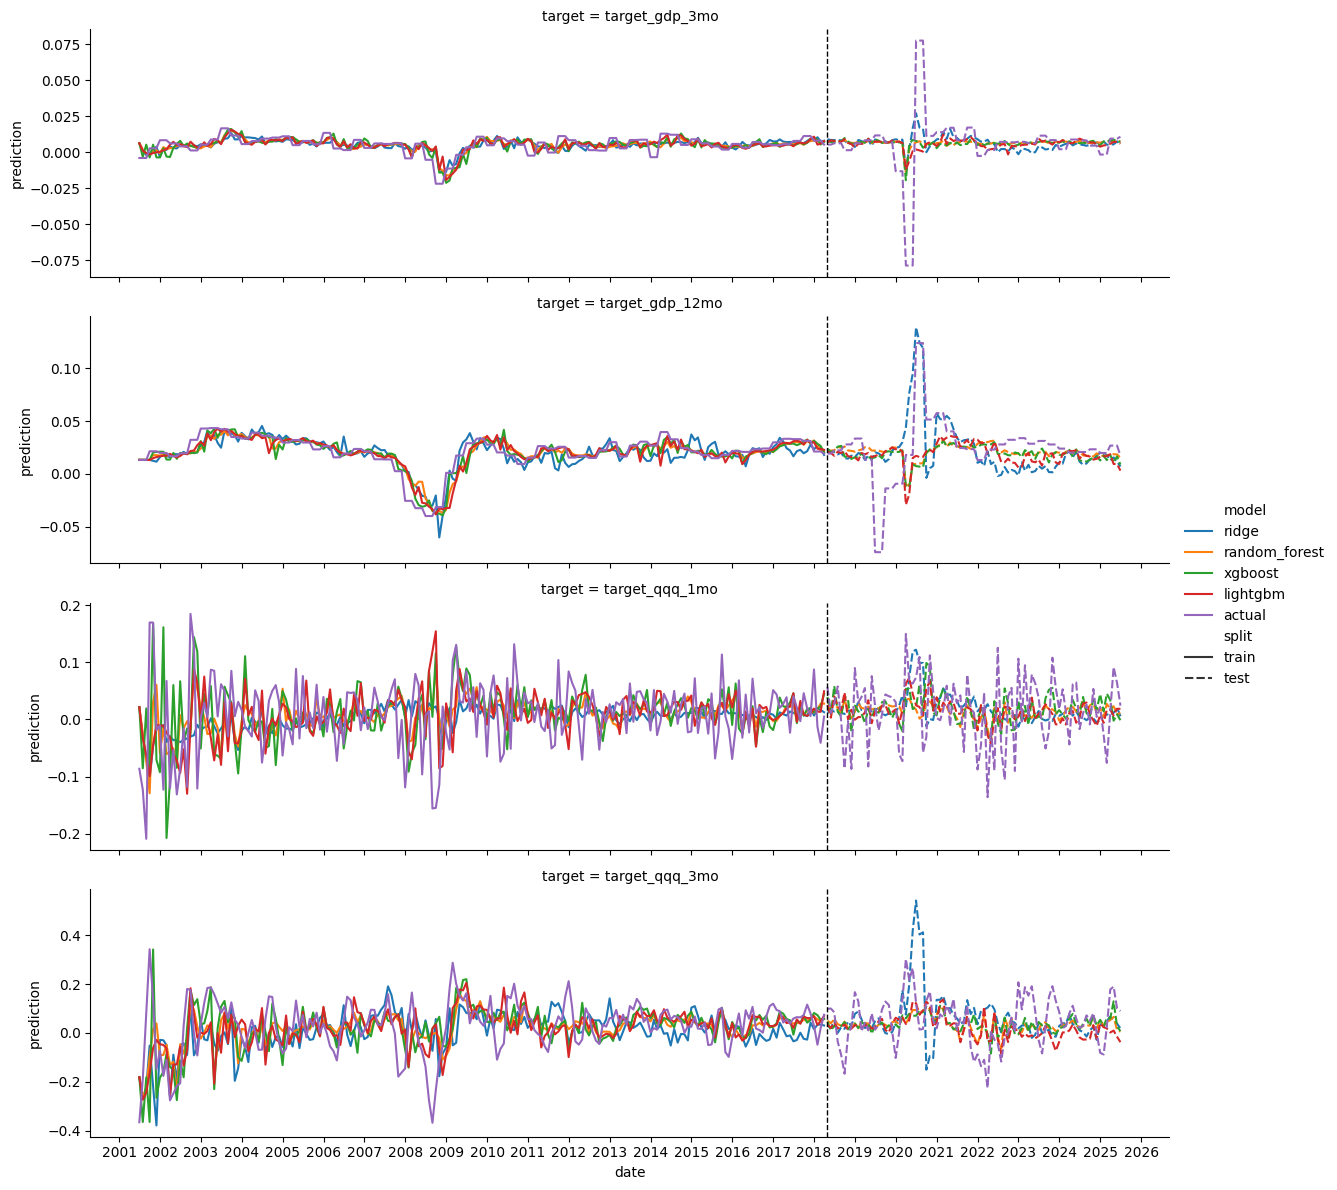

In [53]:
# display(results.head())
plot_df = pd.concat([
    results
        .drop(columns=['actual']),
    results
        .drop_duplicates(['date', 'target'])
        .drop(columns=['prediction'])
        .rename(columns={'actual':'prediction'})
        .assign(model='actual')
])
# display(plot_df.head())
fg = sns.relplot(plot_df, x='date', y='prediction', row='target', hue='model', style='split',
            kind='line', height=3, aspect=4, facet_kws={'sharey': False, 'sharex': True})
# Add in a verticle line to mark where the train and test sets split.
split_date = results.query('split == "test"')['date'].min()
for ax in fg.axes.flatten():
    ax.axvline(split_date, color='black', linestyle='--', linewidth=1, label='train/test split')

ax = fg.axes[-1][-1]
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1]))  # one tick per year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

### 4.6 Use RMSE to visualize how training went

Use RMSE as measure to get accuracy of model at each training step. I.e., for each window size. That way can validate that the model accuracy is increasing with data size while hopefully not overfitting.

,target,model,split,date,actual,prediction,rmse,rmse_6mo_avg
0,target_gdp_3mo,ridge,train,2001-06-30 00:00:00,-0.004006,0.006245,0.010251,NaN
1,target_gdp_3mo,ridge,train,2001-07-31 00:00:00,-0.004006,0.001318,0.005324,NaN
2,target_gdp_3mo,ridge,train,2001-08-31 00:00:00,-0.004006,-0.001935,0.002071,NaN
3,target_gdp_3mo,ridge,train,2001-09-30 00:00:00,0.002748,-0.001184,0.003932,NaN
4,target_gdp_3mo,ridge,train,2001-10-31 00:00:00,0.002748,0.001903,0.000845,NaN
5,target_gdp_3mo,ridge,train,2001-11-30 00:00:00,0.002748,0.003843,0.001096,0.00392


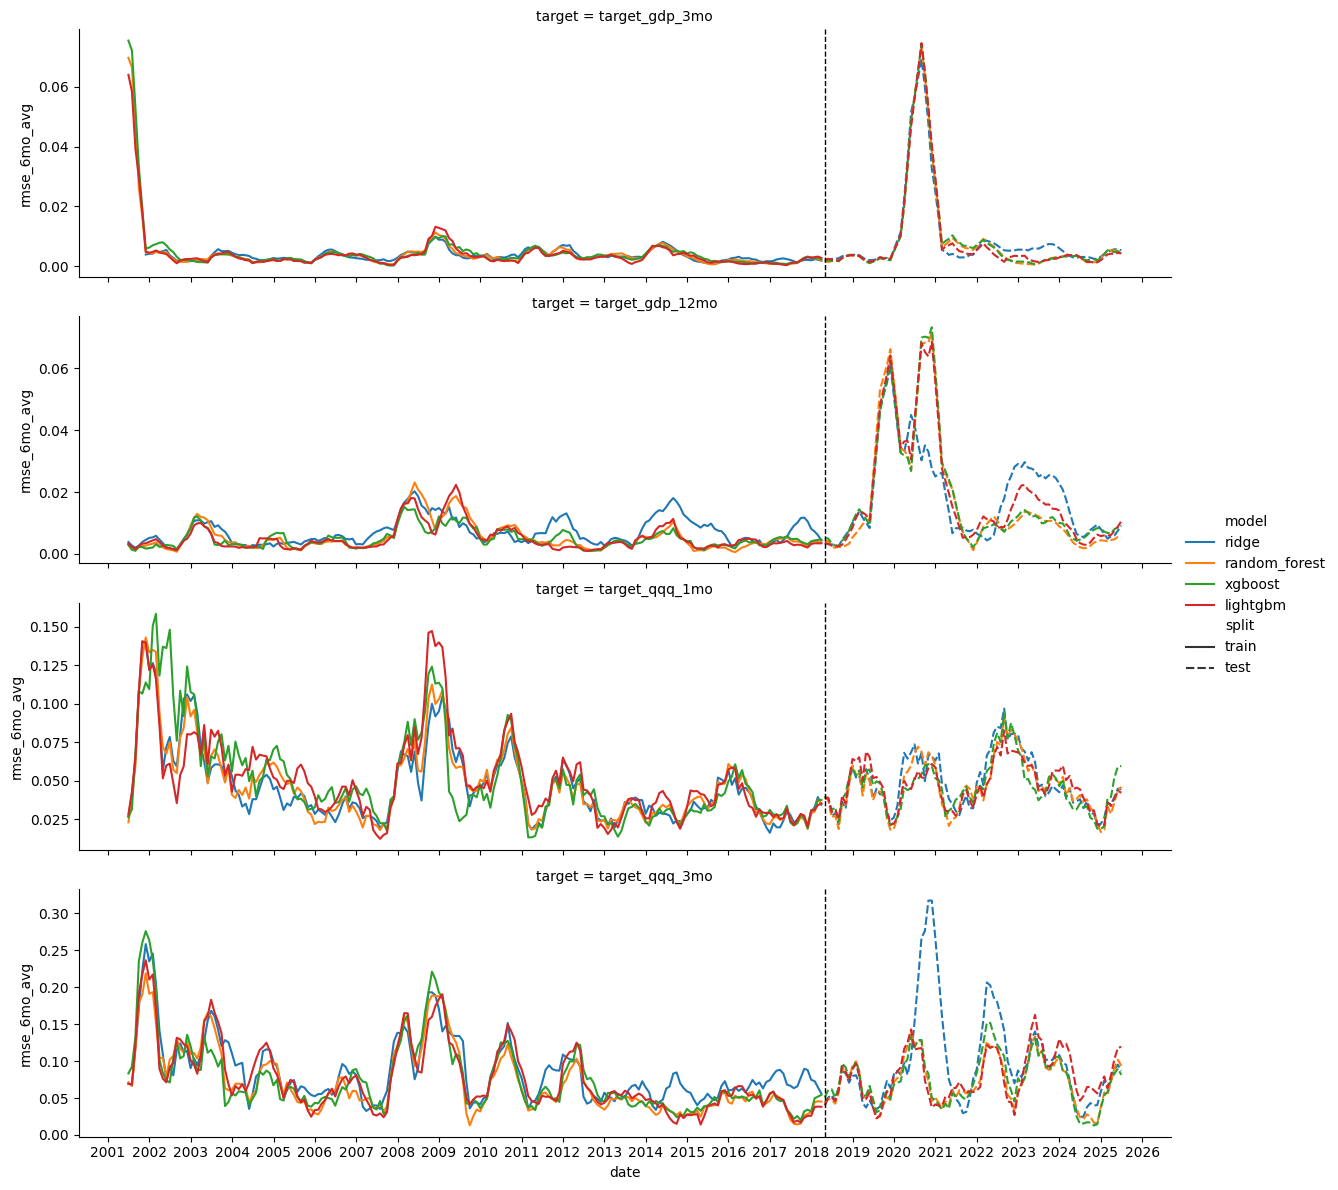

In [54]:
# Calculate the rmse of each data point individually (equivalent to absolute mean error)
# and then take the 6 month rolling average of these to plot the error during training.
# I do this so that I can identify times where the models struggle, either during training
# or in the test data. 
plot_df = results.copy()
plot_df['rmse'] = np.abs(plot_df['actual'] - plot_df['prediction'])
plot_df['rmse_6mo_avg'] = plot_df['rmse'].rolling(window=6).mean()
display(plot_df.head(6))
fg = sns.relplot(plot_df, x='date', y='rmse_6mo_avg', row='target', hue='model', style='split',
            kind='line', height=3, aspect=4, facet_kws={'sharey': False, 'sharex': True})

# Add in a verticle line to mark where the train and test sets split.
split_date = results.query('split == "test"')['date'].min()
for ax in fg.axes.flatten():
    ax.axvline(split_date, color='black', linestyle='--', linewidth=1, label='train/test split')

ax = fg.axes[-1][-1]
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1]))  # one tick per year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

We can see from these plots that the RMSE error drops off very quickly after training starts for each method for GDP targets, and more gradually for QQQ.

There are also marked increases in error around 2008-2010, likely due to high volitility in the economy as it reacted to the
2008 subprime mortage crisis, which the models had not seen in previous data.

In the test data we can see that all models for all target variables struggle with increased error during the 2020 COVID
pandemic, as again these models had not previously seen such events in past training data. This means that how the models react 
to this event will have a pronounced effect on their overall error score.

Speaking of which, let's print their RMSE for their predictions on test data. I will also plot the RMSE of a *dumb* model, meaning
a model which simply predicts the mean of the true target values across the training set. If these models can't beat this dumb model
then they aren't really learning anything useful.

In [55]:
for target in target_cols:
    print(f"Target: {target}")
    sub = results.query(f"target == '{target}'").drop_duplicates("date")
    train_actuals = sub.query('split == "train"')['actual']
    test_actuals = sub.query('split == "test"')['actual']

    baseline_val = train_actuals.mean()
    baseline_preds = np.full(test_actuals.shape[0], baseline_val)
    baseline_rmse = root_mean_squared_error(y_true=test_actuals, y_pred=baseline_preds)
    print("\tBaseline:")
    print(f"\t\t{baseline_rmse}")

    for model in models.keys():
        sub = results.query(f"model == '{model}' and target == '{target}'")
        model_preds = sub.query('split == "test"')['prediction']
        model_rmse = root_mean_squared_error(y_true=test_actuals, y_pred=model_preds)
        print(f"\tModel: {model}")
        print(f"\t\t{model_rmse}")

Target: target_gdp_3mo
	Baseline:
		0.02146395314774518
	Model: ridge
		0.01971078550346274
	Model: random_forest
		0.020309283946701537
	Model: xgboost
		0.020578594660723915
	Model: lightgbm
		0.02042308825888403
Target: target_gdp_12mo
	Baseline:
		0.029547384516526
	Model: ridge
		0.02772400075832469
	Model: random_forest
		0.031340911982988544
	Model: xgboost
		0.031303846760852246
	Model: lightgbm
		0.031272071436900375
Target: target_qqq_1mo
	Baseline:
		0.05890422185896202
	Model: ridge
		0.061937301211539994
	Model: random_forest
		0.05759203083361619
	Model: xgboost
		0.05744416590454423
	Model: lightgbm
		0.0569767134895061
Target: target_qqq_3mo
	Baseline:
		0.09954288046434617
	Model: ridge
		0.13465135408853002
	Model: random_forest
		0.09389450820282086
	Model: xgboost
		0.09556455526585278
	Model: lightgbm
		0.10343366851897035


To summarize, this analysis shows that:
- All models perform better than the baseline dumb model for target variable gdp_3mo, with ridge performing the best.
- Only ridge performs better than the baseline dumb model for target variable gdp_12mo, indicating that these features struggle with predicting GDP in the far future. Ridge barely outperforms the baseline model which barely outperforms the tree-based methods. The difference seems to come down to either method responds to a second spike from the COVID pandemic and the changes resulting from FED changes and mass inflation.
- random forest, xgboost and lightgbm all just barely outperformed the baseline dumb model for target variable qqq_1mo. It makes sense that these models would struggle to predict qqq values as I am using publically available data here and more sophisticated models using proprietary data would already take this info into account which would affect QQQ's price until these data are no longer predictive.
- Only random forest and xgboost outperform the dumb model for target variable qqq_3mo. Ridge performs particularly poorly, primarily during the COVID pandemic.

### 4.7 Correlation between predicted values and true values

Beyond just the RMSE error, let's also take a look at the correlation between the true values and each model's predictions. In general, even if the prediction is consistently different than the actual value, it should at least correlate with it so that predicted positive changes end up being positive and negative predictions negative.

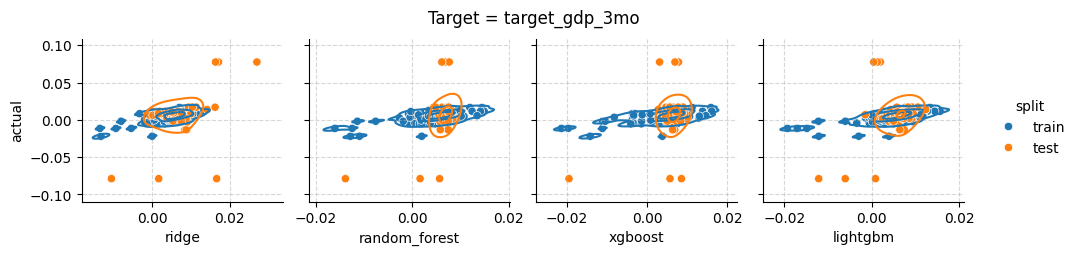

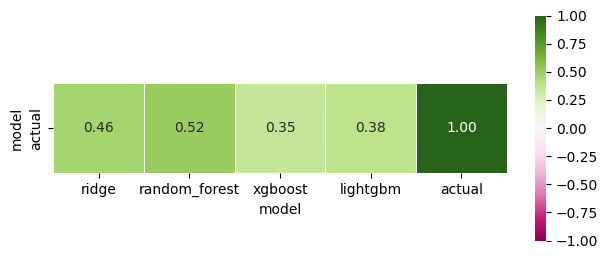

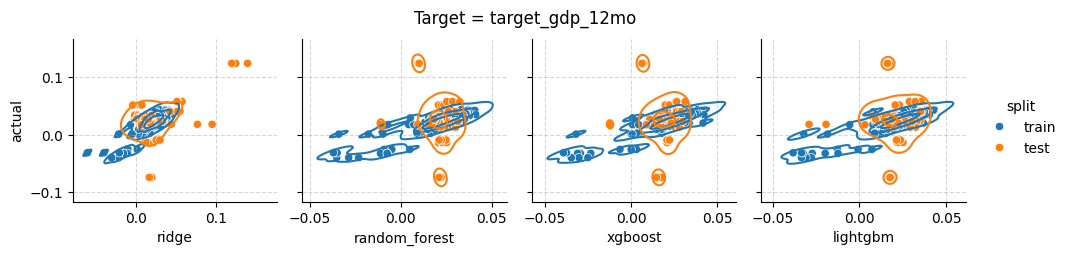

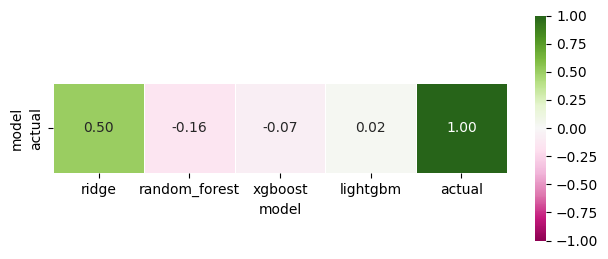

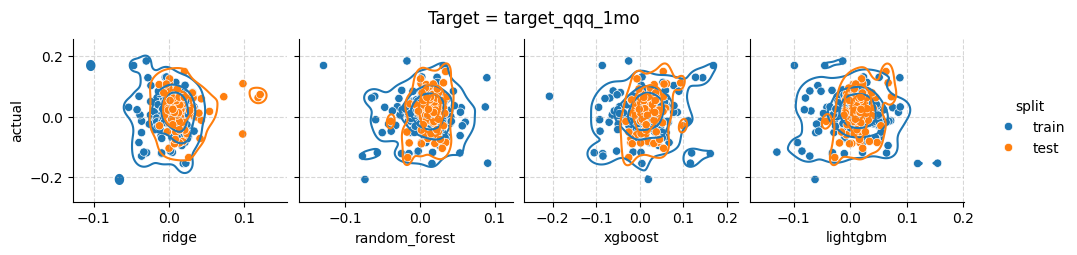

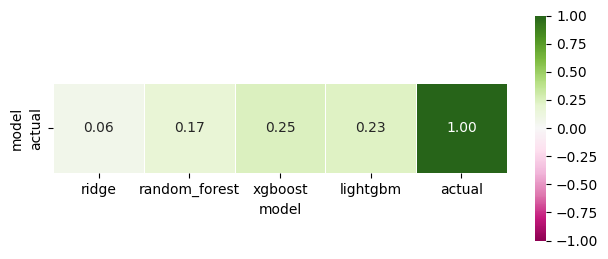

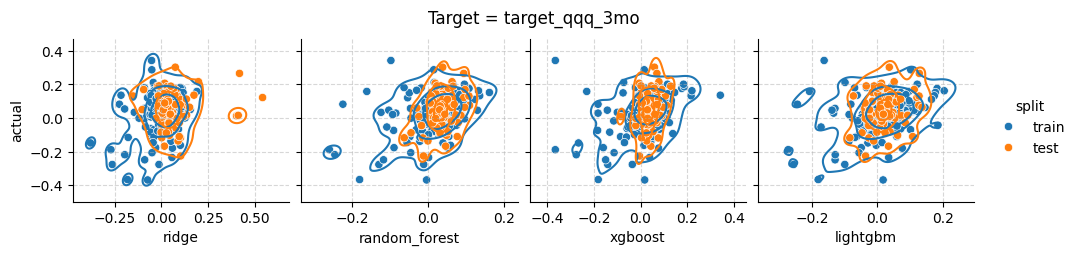

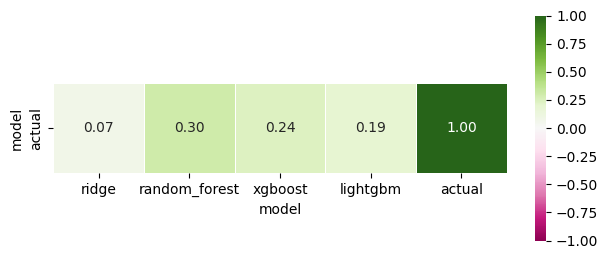

In [56]:
def add_grid(*args, **kwargs):
    plt.gca().grid(True, linestyle='--',alpha=0.5)

for target in target_cols:
    sub = results.query(f"target == '{target}'")
    plot_df = sub.pivot(index='date', columns=['model'], values='prediction')

    plot_df['actual'] = sub.drop_duplicates('date').set_index('date')['actual']
    plot_df['target'] = target
    plot_df['split']  = sub.drop_duplicates('date').set_index('date')['split']


    g = sns.pairplot(plot_df, hue='split',
                     y_vars=['actual'], x_vars=models.keys())

    g.map(add_grid)
    g.map(sns.kdeplot, levels=4, color=".2")
    plt.suptitle(f"Target = {target}")
    g.tight_layout()
    plt.show()


    cols = list(models.keys()) + ["actual"]
    corr_mat = plot_df.query("split == 'test'")[cols].corr()
    # sns.clustermap(corr_mat, vmin=-1, vmax=1, center = 0, cmap = "PiYG")
    sns.heatmap(corr_mat.loc[['actual']], vmin=-1, vmax=1, center = 0, cmap = "PiYG",
                 annot=True, fmt='.2f', linewidths=0.5, square=True, cbar_kws={'shrink': 0.5})
    plt.tight_layout()
    plt.show()



We can see from these figures that the model's predictions often do not correlate well with the actual values in the test sets. This is especially apparent for GDP changes that occurred during the COVID pandemic. Here there were large swings of approximately -8% and 8% with the models predictions being heavily restrained between -3% and 2%. This is most likely because such an event was not captured in these model's training data.

For the GDP targets (3mo and 12mo), the ridge models correlate very well. Although random forest correlates slightly better than ridge for GDP_3mo. Random forest and xgboost actually becoming negatively correlated for 12mo. 

Correlations with QQQ are generally positive although of smaller magnitude. XGBoost and LightGBM seems to correlate the best with QQQ_1mo. Considering LightGBM also had the lowest RMSE error, I will use this model when developing a buying / selling method for QQQ in the next section.

### 4.8 Developing a buy and sell method

Will compare to a buy-and-hold method

My buy-and-sell method will be simple:
- if the model predicts gains higher than current interest rates, buy qqq.
- if not, then switch to 1-month bonds.


In [57]:
def run_dumb_buyhold_method(actuals):
    '''
    Super simple buy-and-hold method. Just buy $1 of ETF at the
    beginning of the period and never sell, taking all gains
    and losses as time passes.
    
    Input: Percent change in ETF value every month
    Output: resulting value if just $1 was originally invested.
    '''
    money = 1
    for a in actuals:
        money = money*(1+a)
    return money


def run_model_informed_buysell_method(predictions, actuals, fed_rates):
    '''
    Let's keep this simple. If the model predicts a positive return, 
    invest in the ETF. Otherwise put money into a 1-month bond that 
    we will say has the same return as the fed_interest_rate.
    
    Input: predicted percent change, actual percent change, and fed
           rates for that month
    Output: resulting value if just $1 was originally invested.
    '''

    assert len(actuals) == len(predictions)

    money = 1
    for i in range(len(actuals)):
        if predictions[i] > 0:
            money = money*(1+actuals[i])
        else:
            money = money*(1+fed_rates[i]/12)
    return money

In [58]:
sub = results.query('model == "lightgbm" and split == "test" and target == "target_qqq_1mo"')
# sub.head()
actuals = sub['actual']
predictions = sub['prediction']

# fed_funds_rate in feature_matrix has been z-scored (see notebook 3's StandardScaler step), so
# it can't be used as an actual interest rate here. Load the raw, pre-scaling value instead.
# FRED's FEDFUNDS series is reported in percentage points (e.g. 1.69 means 1.69%), so divide by
# 100 to get a fraction before converting the annual rate to a monthly one.
raw_market_df = pd.read_csv(PROCESSED_DATA_DIR / "processed_market_data.csv", index_col=0)
raw_market_df.index = pd.to_datetime(raw_market_df.index)
fed_rates = raw_market_df.loc[sub['date'], 'fed_funds_rate'] / 100

buy_hold_money_earned = run_dumb_buyhold_method(actuals.to_list())
model_informed_money_earned = run_model_informed_buysell_method(predictions.to_list(), actuals.to_list(), fed_rates.to_list())

print(f"Buy and hold turned $1 into ${buy_hold_money_earned:.2f}")
print(f"Model-informed method turned $1 into ${model_informed_money_earned:.2f}")

Buy and hold turned $1 into $3.68
Model-informed method turned $1 into $3.99


The model-informed method actually performed better than the buy-and hold. This fits in nicely with what we saw earlier in that the LightGBM model correlated with the actual values a little bit so that with this buy/sell method we should have bought QQQ on more positive months and sold on more negative months than the buy-and-hold method. 

Although with their values being so close it is entirely possible that the difference is caused basically by luck. I actually expect that this is due to luck due to the efficient market hypothesis, which I referenced earlier. To determine if the models here can be used to outcompete buy-and-hold, I would likely need more data, which I can acquire by waiting longer or potentially by increasing the sampling rate to weekly.